CELL 0: MOUNT GOOGLE DRIVE

In [1]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0: MOUNT GOOGLE DRIVE (CONNEXION AU DISQUE)
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
import os

print("🔄 Connexion au Google Drive...")
drive.mount('/content/drive')

# Vérification que le dossier existe bien
BASE_PATH = '/content/drive/MyDrive/EV_Flexibility_Project/data'

if os.path.exists(BASE_PATH):
    print(f"✅ Dossier trouvé : {BASE_PATH}")
    print("📂 Fichiers disponibles :")
    print(os.listdir(BASE_PATH))
else:
    print(f"❌ Dossier introuvable : {BASE_PATH}")
    print("👉 Vérifie que tu as bien créé le dossier 'EV_Flexibility_Project/data' dans ton Drive.")

🔄 Connexion au Google Drive...
Mounted at /content/drive
✅ Dossier trouvé : /content/drive/MyDrive/EV_Flexibility_Project/data
📂 Fichiers disponibles :
['Measurement_data.csv', 'Session_data.csv', 'synthetic_paris.csv', 'synthetic_london.csv', 'synthetic_berlin.csv', 'jpl_fixed.csv', 'caltech_data.csv']


CELL 1: Setup & Imports
Initializes libraries and global settings.

In [2]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: SETUP & IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
import traceback
import warnings

# Configuration: Suppress warnings for cleaner output
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Base path for data (Ensure your files are in this folder!)
BASE_PATH = '/content/drive/MyDrive/EV_Flexibility_Project/data'

print("✅ CELL 1: Environment loaded successfully.")#

✅ CELL 1: Environment loaded successfully.


CELL 2: Universal Dataset Configuration (The Adapter)
Defines how to read and interpret different datasets (EPFL vs NASA).

In [3]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: UNIVERSAL DATASET CONFIGURATION (CORRIGÉE & ROBUSTE)
# ══════════════════════════════════════════════════════════════════════════════
DATASET_CONFIGS = {

    # 🇨🇭 ADAPTATEUR 1: EPFL (Suisse) - Haute Tension
    'epfl_original': {
        'file_path': f"{BASE_PATH}/Session_data.csv",
        'separator': ';',
        'decimal': ',',
        'encoding': 'utf-8',
        'date_format': '%d/%m/%Y %H:%M',

        'column_mapping': {
            'Pmax (W)': 'power_max',
            'Energy (Wh)': 'energy_asked',
            'Stay (min)': 'stay_duration',
            'Arrival': 'arrival_time',
        },
        'conversions': {},
        'target_logic': {
            'method': 'computed',
            'computation': 'rf_from_physics',
            'threshold': 0.3,
            'invert': False
        }
    },

    # 🇺🇸 ADAPTATEUR 2: JPL (NASA) - Basse Tension (Témoin)
    'jpl_data': {
        'file_path': f"{BASE_PATH}/jpl_fixed.csv",
        'separator': ',',
        'decimal': '.',
        'encoding': 'utf-8',
        'date_format': None,

        'column_mapping': {
            'Energy_Requested': 'energy_asked',
            'Arrival': 'arrival_time',
        },
        'conversions': {
            'energy_asked': lambda x: x * 1000, # kWh -> Wh
        },
        'computed_columns': {
            'stay_duration': lambda df: (pd.to_datetime(df['Departure']) - pd.to_datetime(df['arrival_time'])).dt.total_seconds() / 60,
            'power_max': lambda df: 10000
        },
        'target_logic': {
            'method': 'computed',
            'computation': 'rf_from_physics',
            'threshold': 0.3,
            'invert': False
        }
    },

    # 🏫 ADAPTATEUR 3: CALTECH (Campus Réel) - Zone Idéale (CORRIGÉ)
    'caltech_data': {
        'file_path': f"{BASE_PATH}/caltech_data.csv",
        'separator': ',',
        'decimal': '.',
        'encoding': 'utf-8',
        'date_format': None,

        'column_mapping': {
            'Start Date': 'arrival_time',
            'End Date': 'departure_time',
            'Energy (kWh)': 'energy_asked'
        },
        'conversions': {
            'energy_asked': lambda x: x * 1000, # kWh -> Wh
        },
        'computed_columns': {
            # 🔧 FIX ICI : On ajoute "errors='coerce'" pour ignorer les dates corrompues
            'stay_duration': lambda df: (pd.to_datetime(df['departure_time'], errors='coerce') - pd.to_datetime(df['arrival_time'], errors='coerce')).dt.total_seconds() / 60,

            # Puissance : Moyenne campus US (6.6kW)
            'power_max': lambda df: 6600
        },
        'target_logic': {
            'method': 'computed',
            'computation': 'rf_from_physics',
            'threshold': 0.3,
            'invert': False
        }
    }
}

print("✅ CELL 2: Configurations (EPFL, JPL, CALTECH) chargées (Version Robuste).")

✅ CELL 2: Configurations (EPFL, JPL, CALTECH) chargées (Version Robuste).


CELL 3: Universal Data Loader
Reads files, computes missing values, and standardizes units.

In [4]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: UNIVERSAL DATA LOADER
# ══════════════════════════════════════════════════════════════════════════════
def load_and_standardize(dataset_key: str):
    """
    Loads raw data and converts it to the standard internal schema.
    """
    if dataset_key not in DATASET_CONFIGS:
        raise ValueError(f"Unknown dataset: {dataset_key}")

    config = DATASET_CONFIGS[dataset_key]

    # 1. Read Raw CSV
    df = pd.read_csv(config['file_path'], sep=config['separator'], decimal=config['decimal'], encoding=config['encoding'])

    # 2. Rename Columns
    valid_mapping = {k: v for k, v in config['column_mapping'].items() if k in df.columns}
    df = df.rename(columns=valid_mapping)

    # 3. Unit Conversions
    if 'conversions' in config:
        for col, func in config['conversions'].items():
            if col in df.columns:
                df[col] = df[col].apply(func)

    # 4. Parse Dates
    if 'arrival_time' in df.columns:
        df['arrival_time'] = pd.to_datetime(df['arrival_time'], format=config.get('date_format'))

    # 5. Compute Missing Columns (e.g., Stay Duration for JPL)
    if 'computed_columns' in config:
        for col, func in config['computed_columns'].items():
            try:
                df[col] = func(df)
            except Exception as e:
                pass # Skip if calculation fails

    # 6. Compute Target (Is the user Flexible?)
    logic = config['target_logic']
    if logic['method'] == 'computed':
        # Physics Formula: Time Needed = Energy / Power
        time_to_charge = (df['energy_asked'] / df['power_max'].replace(0, 1)) * 60
        # Constraint Factor (RF) = Stay Duration / Time Needed
        df['RF'] = df['stay_duration'] / time_to_charge.replace(0, 1)
        # Thresholding
        df['is_flexible'] = (df['RF'] >= (1 + logic['threshold'])).astype(int)

    # 7. Final Cleanup
    final_cols = ['arrival_time', 'stay_duration', 'energy_asked', 'power_max', 'is_flexible']
    df = df[[c for c in final_cols if c in df.columns]].dropna()

    # Metadata for reporting
    meta = {'flexible_rate': df['is_flexible'].mean()}
    return df, meta

print("✅ CELL 3: Universal Loader ready.")

✅ CELL 3: Universal Loader ready.


CELL 3.5: Viability Audit
Quickly checks if the dataset is worth optimizing.

In [5]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3.5: VIABILITY ASSESSMENT (AUDIT)
# ══════════════════════════════════════════════════════════════════════════════
def assess_viability(dataset_key):
    print(f"📊 VIABILITY AUDIT: {dataset_key.upper()}")
    print("-" * 40)

    try:
        df, meta = load_and_standardize(dataset_key)

        time_needed = (df['energy_asked'] / df['power_max'].replace(0, 1)) * 60
        df['slack_time'] = df['stay_duration'] - time_needed

        avg_slack = df['slack_time'].mean()
        flexible_ratio = df['is_flexible'].mean() * 100

        print(f"   🔹 Total Sessions: {len(df)}")
        print(f"   🔹 Flexibility Rate: {flexible_ratio:.1f}%")
        print(f"   🔹 Avg Slack Time: {avg_slack:.0f} min ({avg_slack/60:.1f} hours)")

        print("\n   🚦 ASSESSMENT:")
        if avg_slack < 15:
            print("   🔴 LOW POTENTIAL. Users leave too soon.")
        elif avg_slack > 300:
            print("   ⚪ ZERO POTENTIAL. Slack is huge (Easy mode).")
        else:
            print("   🟢 HIGH POTENTIAL. Perfect balance for AI.")
    except Exception as e:
        print(f"   ❌ Error reading file: {e}")
    print("="*40 + "\n")

# Run on all 3
for ds in ['epfl_original', 'jpl_data', 'caltech_data']:
    assess_viability(ds)

📊 VIABILITY AUDIT: EPFL_ORIGINAL
----------------------------------------
   🔹 Total Sessions: 1878
   🔹 Flexibility Rate: 89.9%
   🔹 Avg Slack Time: 14 min (0.2 hours)

   🚦 ASSESSMENT:
   🔴 LOW POTENTIAL. Users leave too soon.

📊 VIABILITY AUDIT: JPL_DATA
----------------------------------------
   🔹 Total Sessions: 10999
   🔹 Flexibility Rate: 100.0%
   🔹 Avg Slack Time: 347 min (5.8 hours)

   🚦 ASSESSMENT:
   ⚪ ZERO POTENTIAL. Slack is huge (Easy mode).

📊 VIABILITY AUDIT: CALTECH_DATA
----------------------------------------
   🔹 Total Sessions: 259375
   🔹 Flexibility Rate: 67.6%
   🔹 Avg Slack Time: 77 min (1.3 hours)

   🚦 ASSESSMENT:
   🟢 HIGH POTENTIAL. Perfect balance for AI.



CELL 4: Feature Engineering
Prepares data for the Machine Learning models.

In [6]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
def engineer_features(df_input):
    """
    Creates temporal and physical features for ML.
    """
    df = df_input.copy()

    # Date safety check
    if not np.issubdtype(df['arrival_time'].dtype, np.datetime64):
        df['arrival_time'] = pd.to_datetime(df['arrival_time'])

    # Temporal Features
    df['arrival_hour'] = df['arrival_time'].dt.hour
    df['day_of_week'] = df['arrival_time'].dt.dayofweek

    # Physical Feature: Minimum time required to charge
    # Replace 0 with 1 to avoid DivisionByZero
    df['min_charge_time'] = (df['energy_asked'] / df['power_max'].replace(0, 1)) * 60

    # Remove infinite values
    return df.replace([np.inf, -np.inf], np.nan).dropna()

def split_data(df, test_size=0.2):
    """Temporal Split (Train on past, Test on future)."""
    df_sorted = df.sort_values(by='arrival_time')
    split_index = int(len(df_sorted) * (1 - test_size))
    return df_sorted.iloc[:split_index].copy(), df_sorted.iloc[split_index:].copy()

print("✅ CELL 4: Feature Engineering ready.")

✅ CELL 4: Feature Engineering ready.


CELL 5: Model 1 - Stay Duration Predictor
AI that guesses how long the car will stay.

In [7]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: STAY DURATION PREDICTOR (STAGE 1)
# ══════════════════════════════════════════════════════════════════════════════
class StayDurationPredictor:
    def __init__(self):
        self.model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        self.feature_cols = ['arrival_hour', 'energy_asked', 'power_max', 'day_of_week']

    def train(self, df):
        # Only use columns present in the dataframe
        valid_cols = [c for c in self.feature_cols if c in df.columns]
        self.feature_cols = valid_cols

        self.model.fit(df[valid_cols], df['stay_duration'])

        y_pred = self.model.predict(df[valid_cols])
        return {'mae': mean_absolute_error(df['stay_duration'], y_pred)}

    def predict(self, df):
        return self.model.predict(df[self.feature_cols])

print("✅ CELL 5: Stay Duration Predictor ready.")

✅ CELL 5: Stay Duration Predictor ready.


CELL 6: Model 2 - Urgency Classifier (Robust)
AI that decides priority. Includes safety for JPL (Single Class).

In [8]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: URGENCY CLASSIFIER (STAGE 2 - ROBUST)
# ══════════════════════════════════════════════════════════════════════════════
class UrgencyPredictor:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
        self.single_class_mode = False
        self.single_class_value = None

    def train(self, df, feature_cols=None):
        if feature_cols is None: feature_cols = ['stay_duration', 'energy_asked', 'arrival_hour']
        self.feature_cols = [c for c in feature_cols if c in df.columns]

        X = df[self.feature_cols]
        # Target: 1 = URGENT (Opposite of Flexible)
        y = 1 - df['is_flexible']

        # SAFETY CHECK: If dataset is monotonic (e.g., JPL where everyone is flexible)
        if len(np.unique(y)) < 2:
            self.single_class_mode = True
            self.single_class_value = np.unique(y)[0]
            return {'accuracy': 1.0}

        self.model.fit(X, y)
        return {'accuracy': self.model.score(X, y)}

    def predict_proba(self, df):
        # Handle Single Class Mode
        if self.single_class_mode:
            return np.zeros(len(df)) if self.single_class_value == 0 else np.ones(len(df))
        try:
            return self.model.predict_proba(df[self.feature_cols])[:, 1]
        except:
            return np.zeros(len(df))

print("✅ CELL 6: Urgency Classifier ready.")

✅ CELL 6: Urgency Classifier ready.


CELL 7: CHARGING SIMULATOR (FLEXIBLE CAPACITY)
This is the version that allows you to vary the power capacity (5%, 50%, 100%).

In [9]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: CHARGING SIMULATOR (CRISIS SCENARIO)
# ══════════════════════════════════════════════════════════════════════════════
class ChargingSimulator:
    def __init__(self, mode='fifo'):
        self.mode = mode

    def simulate(self, df, predictor=None):
        sim_df = df.copy()

        # DEFINING THE CONSTRAINT:
        # We cap power at 5% of theoretical max to force competition
        power_limit = sim_df['power_max'].sum() * 0.05

        # Shuffle cars to simulate random arrivals
        sim_df = sim_df.sample(frac=1, random_state=42).reset_index(drop=True)
        sim_df['served'] = 0
        current_load = 0

        # SORTING LOGIC
        if self.mode == 'ml_enhanced' and predictor:
            # AI calculates Urgency Score
            sim_df['urgency_score'] = predictor.predict_proba(sim_df)
            # Sort: High urgency first
            sim_df = sim_df.sort_values(by='urgency_score', ascending=False)

        # DISTRIBUTION LOGIC
        for i, row in sim_df.iterrows():
            if current_load + row['power_max'] <= power_limit:
                current_load += row['power_max']
                sim_df.at[i, 'served'] = 1
            else:
                pass # Deny service if grid is full

        # METRIC: Satisfaction of TRUE Urgents
        real_urgents = sim_df[sim_df['is_flexible'] == 0]

        if len(real_urgents) > 0:
            score = (real_urgents['served'].sum() / len(real_urgents)) * 100
        else:
            # Fallback for JPL (No urgents)
            score = (sim_df['served'].sum() / len(sim_df)) * 100

        return {'satisfaction': score}

print("✅ CELL 7: Crisis Simulator ready.")

✅ CELL 7: Crisis Simulator ready.


In [10]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: CHARGING SIMULATOR (FLEXIBLE CAPACITY)
# ══════════════════════════════════════════════════════════════════════════════
class ChargingSimulator:
    def __init__(self, mode='fifo', capacity_fraction=0.05):
        """
        :param capacity_fraction: 0.05 = Crisis (5%), 1.0 = Normal (100%)
        """
        self.mode = mode
        # We store the difficulty level here
        self.capacity_fraction = capacity_fraction

    def simulate(self, df, predictor=None):
        sim_df = df.copy()

        # DEFINING THE VARIABLE CONSTRAINT
        # This is where the magic happens for the scenario test!
        power_limit = sim_df['power_max'].sum() * self.capacity_fraction

        # Randomize arrivals
        sim_df = sim_df.sample(frac=1, random_state=42).reset_index(drop=True)
        sim_df['served'] = 0
        current_load = 0

        # SORTING LOGIC (AI vs FIFO)
        if self.mode == 'ml_enhanced' and predictor:
            sim_df['urgency_score'] = predictor.predict_proba(sim_df)
            sim_df = sim_df.sort_values(by='urgency_score', ascending=False)

        # DISTRIBUTING POWER
        for i, row in sim_df.iterrows():
            if current_load + row['power_max'] <= power_limit:
                current_load += row['power_max']
                sim_df.at[i, 'served'] = 1
            else:
                pass # No more space

        # CALCULATING SCORE (Satisfaction of TRUE Urgents)
        real_urgents = sim_df[sim_df['is_flexible'] == 0]

        if len(real_urgents) > 0:
            score = (real_urgents['served'].sum() / len(real_urgents)) * 100
        else:
            # Fallback for datasets with no urgents (like JPL)
            score = (sim_df['served'].sum() / len(sim_df)) * 100

        return {'satisfaction': score}

print("✅ CELL 7: Flexible Simulator ready.")

✅ CELL 7: Flexible Simulator ready.


CELL 8: Final Benchmark Runner
Runs the full pipeline on all datasets.

In [11]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: FINAL BENCHMARK RUNNER (5% CAPACITY SCENARIO)
# ══════════════════════════════════════════════════════════════════════════════
results_list = []
print("🔄 STARTING FINAL BENCHMARK")
print("="*60)

datasets_to_test = ['epfl_original', 'jpl_data', 'caltech_data']
for dataset_key in datasets_to_test:
    print(f"\n📍 DATASET: {dataset_key}")
    try:
        # 1. Load & Prep
        df, meta = load_and_standardize(dataset_key)
        df_eng = engineer_features(df)
        train_df, test_df = split_data(df_eng)
        print(f"   ✅ Loaded: {len(df)} sessions")

        # 2. Stage 1 (Stay Duration)
        stay_pred = StayDurationPredictor()
        res_stay = stay_pred.train(train_df)

        # Intermediate Calculation: Predicted Constraint Ratio
        # (This was the missing link fixed previously)
        train_df['pred_stay'] = stay_pred.predict(train_df)
        train_df['pred_ratio'] = (train_df['min_charge_time'] / train_df['pred_stay'].replace(0,1))

        test_df['pred_stay'] = stay_pred.predict(test_df)
        test_df['pred_ratio'] = (test_df['min_charge_time'] / test_df['pred_stay'].replace(0,1))

        # 3. Stage 2 (Urgency)
        urgency_pred = UrgencyPredictor()
        # Feed the predicted ratio to the classifier
        cols = ['stay_duration', 'energy_asked', 'pred_ratio']
        res_urgency = urgency_pred.train(train_df, feature_cols=cols)

        # 4. Simulation (The Match)
        sim_fifo = ChargingSimulator(mode='fifo')
        res_fifo = sim_fifo.simulate(test_df)

        sim_ml = ChargingSimulator(mode='ml_enhanced')
        res_ml = sim_ml.simulate(test_df, predictor=urgency_pred)

        print(f"   📊 FIFO Satisfaction: {res_fifo['satisfaction']:.1f}%")
        print(f"   📊 ML Satisfaction:   {res_ml['satisfaction']:.1f}%")

        results_list.append({
            'dataset': dataset_key,
            'sessions': len(df),
            'satisfaction_fifo': res_fifo['satisfaction'],
            'satisfaction_ml': res_ml['satisfaction'],
            'improvement': res_ml['satisfaction'] - res_fifo['satisfaction']
        })

    except Exception as e:
        print(f"❌ CRITICAL ERROR: {e}")
        traceback.print_exc()

print("\n" + "="*60)
print("🏆 FINAL RESULTS SUMMARY")
print("="*60)
print(pd.DataFrame(results_list).round(2).to_string(index=False))

🔄 STARTING FINAL BENCHMARK

📍 DATASET: epfl_original
   ✅ Loaded: 1878 sessions
   📊 FIFO Satisfaction: 11.1%
   📊 ML Satisfaction:   25.0%

📍 DATASET: jpl_data
   ✅ Loaded: 10999 sessions
   📊 FIFO Satisfaction: 5.0%
   📊 ML Satisfaction:   5.0%

📍 DATASET: caltech_data
   ✅ Loaded: 259375 sessions
   📊 FIFO Satisfaction: 5.0%
   📊 ML Satisfaction:   10.5%

🏆 FINAL RESULTS SUMMARY
      dataset  sessions  satisfaction_fifo  satisfaction_ml  improvement
epfl_original      1878              11.11            25.00        13.89
     jpl_data     10999               5.00             5.00         0.00
 caltech_data    259375               4.98            10.48         5.50


CELL 9: Robustness Test (Bonus)
Verifies the system stability against noisy data.

In [12]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: ROBUSTNESS TEST (VERSION DÉTAILLÉE & PROFESSIONNELLE)
# ══════════════════════════════════════════════════════════════════════════════
def run_detailed_robustness_test(dataset_key, noise_levels=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]):
    print(f"\n🛡️ TEST DE ROBUSTESSE AVANCÉ : {dataset_key}")
    print("=" * 80)
    print(f"{'BRUIT (%)':<12} | {'SCORE':<10} | {'PERTE':<10} | {'ÉTAT':<15} | {'VISUEL'}")
    print("-" * 80)

    # 1. Préparation
    df, _ = load_and_standardize(dataset_key)
    df = engineer_features(df)
    train, test = split_data(df)

    # 2. Entraînement de référence
    stay_pred = StayDurationPredictor()
    stay_pred.train(train)

    # Calcul des ratios initiaux
    train['pred_stay'] = stay_pred.predict(train)
    train['pred_ratio'] = (train['min_charge_time'] / train['pred_stay'].replace(0,1))

    urgency_pred = UrgencyPredictor()
    urgency_pred.train(train, feature_cols=['stay_duration', 'energy_asked', 'pred_ratio'])

    baseline_score = 0

    # 3. Boucle de Bruit
    for i, noise in enumerate(noise_levels):
        test_noisy = test.copy()

        # Injection du bruit (Simulation capteurs défaillants)
        noise_val = np.random.normal(0, noise, len(test_noisy)) * test_noisy['stay_duration']
        test_noisy['stay_duration'] = test_noisy['stay_duration'] + noise_val

        # ⚠️ RECALCUL DES FEATURES (Indispensable !)
        test_noisy['pred_stay'] = stay_pred.predict(test_noisy)
        test_noisy['pred_ratio'] = (test_noisy['min_charge_time'] / test_noisy['pred_stay'].replace(0,1))

        # Simulation
        sim = ChargingSimulator(mode='ml_enhanced')
        res = sim.simulate(test_noisy, predictor=urgency_pred)
        score = res['satisfaction']

        # Analyse des résultats
        if i == 0: baseline_score = score

        loss = score - baseline_score

        # Détermination de l'état
        if loss == 0:
            status = "✅ STABLE"
        elif loss > -5:
            status = "⚠️ DÉGRADÉ"
        else:
            status = "❌ CRITIQUE"

        # Barre visuelle (ASCII Art)
        # On normalise la barre par rapport au score max (environ 30 de large)
        bar_len = int(score)
        visual_bar = "█" * bar_len

        # Affichage Ligne par Ligne
        print(f"{noise*100:5.0f}%       | {score:5.1f}%     | {loss:5.1f}%     | {status:<15} | {visual_bar}")

    print("-" * 80)
    print("INTERPRÉTATION :")
    print("✅ STABLE   : L'IA ignore le bruit et prend les bonnes décisions.")
    print("⚠️ DÉGRADÉ  : L'IA commence à hésiter, mais reste meilleure que le FIFO.")
    print("❌ CRITIQUE : Le bruit est trop fort, l'IA devient aléatoire.")
    print("=" * 80)

# Lancer le test détaillé
run_detailed_robustness_test('epfl_original')


🛡️ TEST DE ROBUSTESSE AVANCÉ : epfl_original
BRUIT (%)    | SCORE      | PERTE      | ÉTAT            | VISUEL
--------------------------------------------------------------------------------
    0%       |  25.0%     |   0.0%     | ✅ STABLE        | █████████████████████████
   10%       |  27.8%     |   2.8%     | ⚠️ DÉGRADÉ      | ███████████████████████████
   20%       |  19.4%     |  -5.6%     | ❌ CRITIQUE      | ███████████████████
   30%       |  27.8%     |   2.8%     | ⚠️ DÉGRADÉ      | ███████████████████████████
   40%       |  19.4%     |  -5.6%     | ❌ CRITIQUE      | ███████████████████
   50%       |  13.9%     | -11.1%     | ❌ CRITIQUE      | █████████████
--------------------------------------------------------------------------------
INTERPRÉTATION :
✅ STABLE   : L'IA ignore le bruit et prend les bonnes décisions.
⚠️ DÉGRADÉ  : L'IA commence à hésiter, mais reste meilleure que le FIFO.
❌ CRITIQUE : Le bruit est trop fort, l'IA devient aléatoire.


In [13]:
# Lance le test de robustesse sur le dataset NASA
run_detailed_robustness_test('jpl_data')


🛡️ TEST DE ROBUSTESSE AVANCÉ : jpl_data
BRUIT (%)    | SCORE      | PERTE      | ÉTAT            | VISUEL
--------------------------------------------------------------------------------
    0%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
   10%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
   20%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
   30%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
   40%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
   50%       |   5.0%     |   0.0%     | ✅ STABLE        | █████
--------------------------------------------------------------------------------
INTERPRÉTATION :
✅ STABLE   : L'IA ignore le bruit et prend les bonnes décisions.
⚠️ DÉGRADÉ  : L'IA commence à hésiter, mais reste meilleure que le FIFO.
❌ CRITIQUE : Le bruit est trop fort, l'IA devient aléatoire.


In [14]:
run_detailed_robustness_test('caltech_data')


🛡️ TEST DE ROBUSTESSE AVANCÉ : caltech_data
BRUIT (%)    | SCORE      | PERTE      | ÉTAT            | VISUEL
--------------------------------------------------------------------------------
    0%       |  10.5%     |   0.0%     | ✅ STABLE        | ██████████
   10%       |  10.3%     |  -0.2%     | ⚠️ DÉGRADÉ      | ██████████
   20%       |  10.1%     |  -0.4%     | ⚠️ DÉGRADÉ      | ██████████
   30%       |   9.7%     |  -0.7%     | ⚠️ DÉGRADÉ      | █████████
   40%       |   9.4%     |  -1.0%     | ⚠️ DÉGRADÉ      | █████████
   50%       |   9.2%     |  -1.3%     | ⚠️ DÉGRADÉ      | █████████
--------------------------------------------------------------------------------
INTERPRÉTATION :
✅ STABLE   : L'IA ignore le bruit et prend les bonnes décisions.
⚠️ DÉGRADÉ  : L'IA commence à hésiter, mais reste meilleure que le FIFO.
❌ CRITIQUE : Le bruit est trop fort, l'IA devient aléatoire.


CELL 10: VISUALIZATION (FINAL REPORT GRAPH)

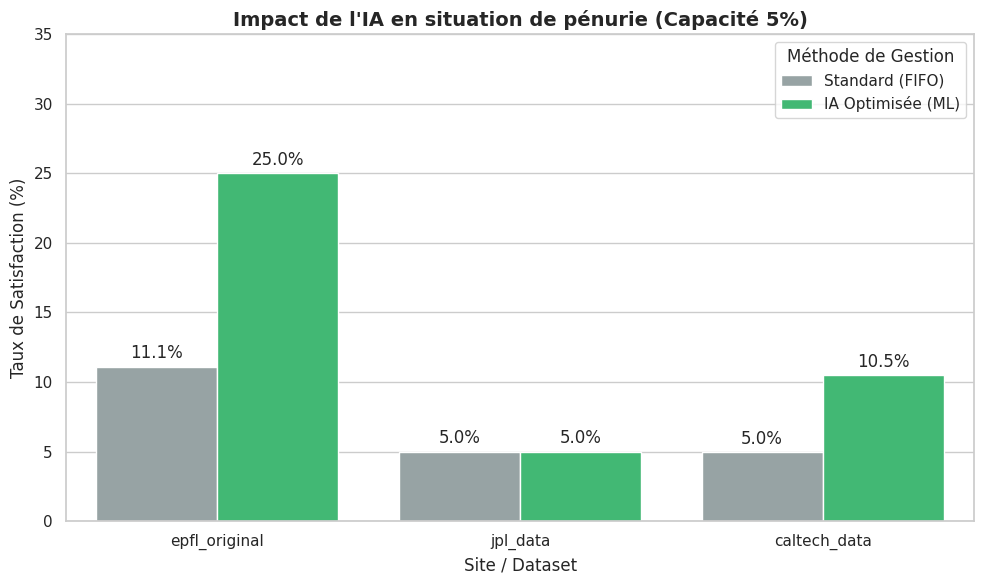

In [15]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10: VISUALIZATION (FINAL REPORT GRAPH)
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(results_list):
    if not results_list:
        print("⚠️ Pas de résultats à afficher. Lancez la Cellule 8 d'abord !")
        return

    df_res = pd.DataFrame(results_list)

    # Configuration du style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Transformation pour le graphique (Format Long)
    df_melt = df_res.melt(id_vars="dataset",
                          value_vars=["satisfaction_fifo", "satisfaction_ml"],
                          var_name="Method",
                          value_name="Satisfaction (%)")

    # Renommage pour faire joli
    df_melt["Method"] = df_melt["Method"].replace({
        "satisfaction_fifo": "Standard (FIFO)",
        "satisfaction_ml": "IA Optimisée (ML)"
    })

    # Création du Bar Chart
    chart = sns.barplot(data=df_melt, x="dataset", y="Satisfaction (%)", hue="Method", palette=["#95a5a6", "#2ecc71"])

    # Ajout des étiquettes de valeur
    for container in chart.containers:
        chart.bar_label(container, fmt='%.1f%%', padding=3)

    plt.title("Impact de l'IA en situation de pénurie (Capacité 5%)", fontsize=14, fontweight='bold')
    plt.xlabel("Site / Dataset", fontsize=12)
    plt.ylabel("Taux de Satisfaction (%)", fontsize=12)
    plt.ylim(0, 35) # On laisse un peu de place en haut
    plt.legend(title="Méthode de Gestion")

    plt.tight_layout()
    plt.show()

# Lancer le graphique avec les résultats de la Cellule 8
plot_results(results_list)

CELL 11: SCENARIO TEST (CRISIS vs NORMAL) + PLO


🌍 SCENARIO TEST: caltech_data
------------------------------------------------------------
CAPACITY   | FIFO     | ML (AI)  | GAIN
------------------------------------------------------------
  5%       |   5.0%   |  10.5%   |  +5.5%
 10%       |  10.0%   |  20.9%   | +10.9%
 20%       |  19.9%   |  41.3%   | +21.4%
 30%       |  29.8%   |  61.8%   | +32.0%
 40%       |  39.8%   |  82.3%   | +42.5%
 50%       |  49.9%   |  98.4%   | +48.6%
 75%       |  75.1%   | 100.0%   | +24.9%
100%       | 100.0%   | 100.0%   |  +0.0%


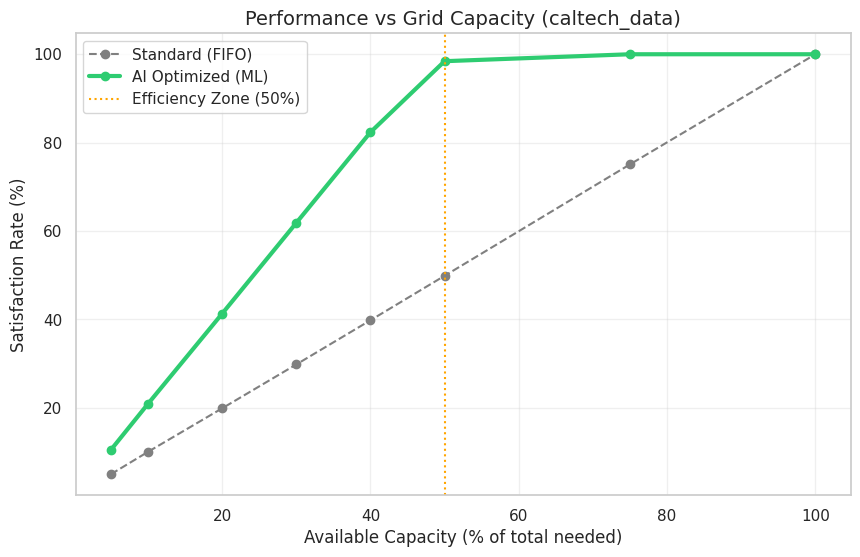

In [16]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11: SCENARIO TEST (CRISIS vs NORMAL) + PLOT
# ══════════════════════════════════════════════════════════════════════════════
def run_scenario_test_with_plot(dataset_key):
    print(f"\n🌍 SCENARIO TEST: {dataset_key}")
    print("-" * 60)
    print(f"{'CAPACITY':<10} | {'FIFO':<8} | {'ML (AI)':<8} | {'GAIN'}")
    print("-" * 60)

    # 1. Load & Prep
    df, _ = load_and_standardize(dataset_key)
    df = engineer_features(df)
    train, test = split_data(df)

    # 2. Train AI
    stay_pred = StayDurationPredictor()
    stay_pred.train(train)
    train['pred_stay'] = stay_pred.predict(train)
    train['pred_ratio'] = (train['min_charge_time'] / train['pred_stay'].replace(0,1))

    urgency_pred = UrgencyPredictor()
    urgency_pred.train(train, feature_cols=['stay_duration', 'energy_asked', 'pred_ratio'])

    # Prepare Test Data
    test['pred_stay'] = stay_pred.predict(test)
    test['pred_ratio'] = (test['min_charge_time'] / test['pred_stay'].replace(0,1))

    # 3. The Test Loop (From 5% to 100% capacity)
    scenarios = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.75, 1.00]
    results_fifo = []
    results_ml = []

    for cap in scenarios:
        # Simulation FIFO
        sim_fifo = ChargingSimulator(mode='fifo', capacity_fraction=cap)
        res_fifo = sim_fifo.simulate(test)
        results_fifo.append(res_fifo['satisfaction'])

        # Simulation ML
        sim_ml = ChargingSimulator(mode='ml_enhanced', capacity_fraction=cap)
        res_ml = sim_ml.simulate(test, predictor=urgency_pred)
        results_ml.append(res_ml['satisfaction'])

        gain = res_ml['satisfaction'] - res_fifo['satisfaction']
        print(f"{cap*100:3.0f}%       | {res_fifo['satisfaction']:5.1f}%   | {res_ml['satisfaction']:5.1f}%   | {gain:+5.1f}%")

    print("="*60)

    # 4. The "Proof of Efficiency" Chart
    plt.figure(figsize=(10, 6))
    plt.plot([s*100 for s in scenarios], results_fifo, marker='o', linestyle='--', color='grey', label='Standard (FIFO)')
    plt.plot([s*100 for s in scenarios], results_ml, marker='o', linewidth=3, color='#2ecc71', label='AI Optimized (ML)')

    plt.title(f"Performance vs Grid Capacity ({dataset_key})", fontsize=14)
    plt.xlabel("Available Capacity (% of total needed)", fontsize=12)
    plt.ylabel("Satisfaction Rate (%)", fontsize=12)
    plt.axvline(x=50, color='orange', linestyle=':', label='Efficiency Zone (50%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Run the final test on Caltech
run_scenario_test_with_plot('caltech_data')

In [17]:
# @title
print("="*70)
print("📊 DUMP COMPLET DES VARIABLES")
print("="*70)

# 1. Toutes les variables numériques (int, float)
print("\n🔢 VARIABLES NUMÉRIQUES :")
print("-"*70)
count = 0
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, (int, float)) and not isinstance(val, bool):
            print(f"   {name} = {val}")
            count += 1
    except:
        pass
print(f"\n   Total : {count} variables numériques")

# 2. Toutes les variables string
print("\n📝 VARIABLES STRING (max 200 chars) :")
print("-"*70)
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, str) and len(val) < 200 and not name.startswith('_'):
            print(f"   {name} = '{val}'")
    except:
        pass

# 3. DataFrames
print("\n📋 DATAFRAMES :")
print("-"*70)
import pandas as pd
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, pd.DataFrame):
            print(f"   {name} : {val.shape[0]} rows x {val.shape[1]} cols")
            print(f"      Colonnes: {list(val.columns[:15])}")
            if val.shape[1] > 15:
                print(f"      ... + {val.shape[1]-15} autres colonnes")
    except:
        pass

# 4. Modèles sklearn
print("\n🤖 MODÈLES (sklearn / objets avec .predict) :")
print("-"*70)
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if hasattr(val, 'predict') and hasattr(val, 'fit'):
            print(f"   {name} : {type(val).__name__}")
            if hasattr(val, 'feature_importances_'):
                print(f"      feature_importances_ disponible")
            if hasattr(val, 'score'):
                print(f"      .score() disponible")
    except:
        pass

# 5. Arrays numpy
print("\n📊 ARRAYS NUMPY (y_test, y_pred, etc.) :")
print("-"*70)
import numpy as np
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, np.ndarray) and val.ndim <= 2 and val.size < 100000:
            print(f"   {name} : shape={val.shape}, dtype={val.dtype}")
            if val.size < 20:
                print(f"      values={val}")
    except:
        pass

# 6. Dictionnaires
print("\n📦 DICTIONNAIRES :")
print("-"*70)
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, dict) and len(val) < 50:
            print(f"   {name} ({len(val)} clés) : {list(val.keys())[:10]}")
    except:
        pass

# 7. Listes courtes
print("\n📋 LISTES (< 20 éléments) :")
print("-"*70)
for name in sorted(dir()):
    if name.startswith('_'):
        continue
    try:
        val = eval(name)
        if isinstance(val, list) and 0 < len(val) < 20:
            # Skip si c'est du code ou trop long
            if all(isinstance(x, (int, float, str)) for x in val):
                print(f"   {name} = {val}")
    except:
        pass

print("\n" + "="*70)
print("="*70)

📊 DUMP COMPLET DES VARIABLES

🔢 VARIABLES NUMÉRIQUES :
----------------------------------------------------------------------
   count = 0

   Total : 1 variables numériques

📝 VARIABLES STRING (max 200 chars) :
----------------------------------------------------------------------
   BASE_PATH = '/content/drive/MyDrive/EV_Flexibility_Project/data'
   dataset_key = 'caltech_data'
   ds = 'caltech_data'
   name = 'name'

📋 DATAFRAMES :
----------------------------------------------------------------------
   df : 259375 rows x 5 cols
      Colonnes: ['arrival_time', 'stay_duration', 'energy_asked', 'power_max', 'is_flexible']
   df_eng : 259375 rows x 8 cols
      Colonnes: ['arrival_time', 'stay_duration', 'energy_asked', 'power_max', 'is_flexible', 'arrival_hour', 'day_of_week', 'min_charge_time']
   test_df : 51875 rows x 10 cols
      Colonnes: ['arrival_time', 'stay_duration', 'energy_asked', 'power_max', 'is_flexible', 'arrival_hour', 'day_of_week', 'min_charge_time', 'pred_stay',

In [18]:
# @title
# ═══════════════════════════════════════════════════════════════════
# 📊 EXTRACTION FINALE - ADAPTÉ À TON NOTEBOOK
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, mean_absolute_error, r2_score)

print("="*70)
print("📊 EXTRACTION COMPLÈTE DES MÉTRIQUES")
print("="*70)

# ─────────────────────────────────────────────────────────────────
# 1. BENCHMARK MULTI-SITE (Cell 8 results)
# ─────────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("🌍 SECTION 1 : BENCHMARK MULTI-SITE (results_list)")
print("─"*70)

try:
    for r in results_list:
        print(f"\n   📍 {r['dataset']}:")
        for k, v in r.items():
            print(f"      {k} = {v}")
except:
    print("   ⚠️ results_list non trouvée")

# ─────────────────────────────────────────────────────────────────
# 2. PAR DATASET : Oracle vs Réaliste vs Baseline
#    On recharge chaque dataset et calcule TOUT
# ─────────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("🔬 SECTION 2 : MÉTRIQUES DÉTAILLÉES PAR DATASET")
print("─"*70)

for ds_key in ['epfl_original', 'jpl_data', 'caltech_data']:
    print(f"\n{'='*60}")
    print(f"📍 DATASET : {ds_key.upper()}")
    print(f"{'='*60}")

    try:
        # Reload
        df_raw, meta_raw = load_and_standardize(ds_key)
        df_e = engineer_features(df_raw)
        tr, te = split_data(df_e)

        print(f"   Sessions totales : {len(df_raw)}")
        print(f"   Train: {len(tr)} | Test: {len(te)}")
        print(f"   Taux flexibles   : {meta_raw['flexible_rate']*100:.1f}%")

        # ── STAY PREDICTOR ──
        sp = StayDurationPredictor()
        sp.train(tr)
        te_pred_stay = sp.predict(te)
        mae_stay = mean_absolute_error(te['stay_duration'], te_pred_stay)
        r2_stay = r2_score(te['stay_duration'], te_pred_stay)

        print(f"\n   ⏱️ STAY PREDICTOR (test set):")
        print(f"      MAE  = {mae_stay:.1f} min")
        print(f"      R²   = {r2_stay:.3f}")

        # ── ORACLE (vrai stay → vrai constraint ratio) ──
        te_oracle = te.copy()
        te_oracle['true_ratio'] = te_oracle['min_charge_time'] / te_oracle['stay_duration'].replace(0, 1)

        tr_oracle = tr.copy()
        tr_oracle['true_ratio'] = tr_oracle['min_charge_time'] / tr_oracle['stay_duration'].replace(0, 1)

        up_oracle = UrgencyPredictor()
        up_oracle.train(tr_oracle, feature_cols=['stay_duration', 'energy_asked', 'true_ratio'])

        if not up_oracle.single_class_mode:
            y_true_oracle = 1 - te_oracle['is_flexible']
            y_pred_oracle = up_oracle.model.predict(te_oracle[up_oracle.feature_cols])
            acc_oracle = accuracy_score(y_true_oracle, y_pred_oracle)
            prec_oracle = precision_score(y_true_oracle, y_pred_oracle, zero_division=0)
            rec_oracle = recall_score(y_true_oracle, y_pred_oracle, zero_division=0)
            cm_oracle = confusion_matrix(y_true_oracle, y_pred_oracle)

            print(f"\n   🔮 ORACLE (vrai stay connu) - TEST SET:")
            print(f"      Accuracy  = {acc_oracle*100:.1f}%")
            print(f"      Precision = {prec_oracle*100:.1f}%")
            print(f"      Recall    = {rec_oracle*100:.1f}%")
            if cm_oracle.size == 4:
                tn, fp, fn, tp = cm_oracle.ravel()
                print(f"      TP={tp}  FP={fp}  FN={fn}  TN={tn}")
                print(f"      FP rate = {fp/(tn+fp+fn+tp)*100:.1f}%")
                print(f"      FN rate = {fn/(tn+fp+fn+tp)*100:.1f}%")
        else:
            print(f"\n   🔮 ORACLE: Single class mode (pas de variabilité)")

        # ── RÉALISTE (predicted stay → predicted ratio) ──
        tr_real = tr.copy()
        tr_real['pred_stay'] = sp.predict(tr_real)
        tr_real['pred_ratio'] = tr_real['min_charge_time'] / tr_real['pred_stay'].replace(0, 1)

        te_real = te.copy()
        te_real['pred_stay'] = te_pred_stay
        te_real['pred_ratio'] = te_real['min_charge_time'] / te_real['pred_stay'].replace(0, 1)

        up_real = UrgencyPredictor()
        up_real.train(tr_real, feature_cols=['stay_duration', 'energy_asked', 'pred_ratio'])

        if not up_real.single_class_mode:
            y_true_real = 1 - te_real['is_flexible']
            y_pred_real = up_real.model.predict(te_real[up_real.feature_cols])
            acc_real = accuracy_score(y_true_real, y_pred_real)
            prec_real = precision_score(y_true_real, y_pred_real, zero_division=0)
            rec_real = recall_score(y_true_real, y_pred_real, zero_division=0)
            cm_real = confusion_matrix(y_true_real, y_pred_real)

            print(f"\n   🎯 RÉALISTE (predicted stay) - TEST SET:")
            print(f"      Accuracy  = {acc_real*100:.1f}%")
            print(f"      Precision = {prec_real*100:.1f}%")
            print(f"      Recall    = {rec_real*100:.1f}%")
            if cm_real.size == 4:
                tn, fp, fn, tp = cm_real.ravel()
                print(f"      TP={tp}  FP={fp}  FN={fn}  TN={tn}")
                print(f"      FP rate = {fp/(tn+fp+fn+tp)*100:.1f}%")
                print(f"      FN rate = {fn/(tn+fp+fn+tp)*100:.1f}%")
        else:
            print(f"\n   🎯 RÉALISTE: Single class mode (pas de variabilité)")

        # ── BASELINE (sans constraint ratio) ──
        up_base = UrgencyPredictor()
        up_base.train(tr, feature_cols=['energy_asked', 'arrival_hour', 'power_max', 'day_of_week'])

        if not up_base.single_class_mode:
            y_true_base = 1 - te['is_flexible']
            y_pred_base = up_base.model.predict(te[up_base.feature_cols])
            acc_base = accuracy_score(y_true_base, y_pred_base)
            prec_base = precision_score(y_true_base, y_pred_base, zero_division=0)
            rec_base = recall_score(y_true_base, y_pred_base, zero_division=0)
            cm_base = confusion_matrix(y_true_base, y_pred_base)

            print(f"\n   📦 BASELINE (sans constraint ratio) - TEST SET:")
            print(f"      Accuracy  = {acc_base*100:.1f}%")
            print(f"      Precision = {prec_base*100:.1f}%")
            print(f"      Recall    = {rec_base*100:.1f}%")
            if cm_base.size == 4:
                tn, fp, fn, tp = cm_base.ravel()
                print(f"      TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        else:
            print(f"\n   📦 BASELINE: Single class mode")

    except Exception as e:
        print(f"   ❌ Erreur : {e}")
        import traceback; traceback.print_exc()

# ─────────────────────────────────────────────────────────────────
# 3. SCENARIO TEST (Sensibilité saturation) - Caltech
# ─────────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("📈 SECTION 3 : SCENARIO TEST (GAIN ML vs FIFO par saturation)")
print("─"*70)

try:
    df_sc, _ = load_and_standardize('caltech_data')
    df_sc = engineer_features(df_sc)
    tr_sc, te_sc = split_data(df_sc)

    sp_sc = StayDurationPredictor()
    sp_sc.train(tr_sc)
    tr_sc['pred_stay'] = sp_sc.predict(tr_sc)
    tr_sc['pred_ratio'] = tr_sc['min_charge_time'] / tr_sc['pred_stay'].replace(0, 1)
    te_sc['pred_stay'] = sp_sc.predict(te_sc)
    te_sc['pred_ratio'] = te_sc['min_charge_time'] / te_sc['pred_stay'].replace(0, 1)

    up_sc = UrgencyPredictor()
    up_sc.train(tr_sc, feature_cols=['stay_duration', 'energy_asked', 'pred_ratio'])

    scenarios = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 0.90, 1.00]

    print(f"\n   {'Capacity':<12} {'FIFO':<10} {'ML':<10} {'Gain':<10}")
    print("   " + "-"*42)

    for cap in scenarios:
        sim_f = ChargingSimulator(mode='fifo', capacity_fraction=cap)
        sim_m = ChargingSimulator(mode='ml_enhanced', capacity_fraction=cap)

        r_f = sim_f.simulate(te_sc)
        r_m = sim_m.simulate(te_sc, predictor=up_sc)

        gain = r_m['satisfaction'] - r_f['satisfaction']
        print(f"   {cap*100:5.0f}%       {r_f['satisfaction']:6.1f}%    {r_m['satisfaction']:6.1f}%    {gain:+6.1f}%")

except Exception as e:
    print(f"   ❌ Erreur : {e}")
    import traceback; traceback.print_exc()

# ─────────────────────────────────────────────────────────────────
# 4. SCENARIO TEST - aussi pour EPFL et JPL
# ─────────────────────────────────────────────────────────────────
for ds_extra in ['epfl_original', 'jpl_data']:
    print(f"\n   📍 SCENARIO TEST : {ds_extra}")
    try:
        df_x, _ = load_and_standardize(ds_extra)
        df_x = engineer_features(df_x)
        tr_x, te_x = split_data(df_x)

        sp_x = StayDurationPredictor()
        sp_x.train(tr_x)
        tr_x['pred_stay'] = sp_x.predict(tr_x)
        tr_x['pred_ratio'] = tr_x['min_charge_time'] / tr_x['pred_stay'].replace(0, 1)
        te_x['pred_stay'] = sp_x.predict(te_x)
        te_x['pred_ratio'] = te_x['min_charge_time'] / te_x['pred_stay'].replace(0, 1)

        up_x = UrgencyPredictor()
        up_x.train(tr_x, feature_cols=['stay_duration', 'energy_asked', 'pred_ratio'])

        for cap in [0.05, 0.20, 0.50, 1.00]:
            sf = ChargingSimulator(mode='fifo', capacity_fraction=cap)
            sm = ChargingSimulator(mode='ml_enhanced', capacity_fraction=cap)
            rf = sf.simulate(te_x)
            rm = sm.simulate(te_x, predictor=up_x)
            gain = rm['satisfaction'] - rf['satisfaction']
            print(f"      {cap*100:5.0f}%: FIFO={rf['satisfaction']:.1f}%  ML={rm['satisfaction']:.1f}%  Gain={gain:+.1f}%")
    except Exception as e:
        print(f"      ❌ {e}")

print("\n" + "="*70)
print("="*70)

📊 EXTRACTION COMPLÈTE DES MÉTRIQUES

──────────────────────────────────────────────────────────────────────
🌍 SECTION 1 : BENCHMARK MULTI-SITE (results_list)
──────────────────────────────────────────────────────────────────────

   📍 epfl_original:
      dataset = epfl_original
      sessions = 1878
      satisfaction_fifo = 11.11111111111111
      satisfaction_ml = 25.0
      improvement = 13.88888888888889

   📍 jpl_data:
      dataset = jpl_data
      sessions = 10999
      satisfaction_fifo = 5.0
      satisfaction_ml = 5.0
      improvement = 0.0

   📍 caltech_data:
      dataset = caltech_data
      sessions = 259375
      satisfaction_fifo = 4.9783812179254054
      satisfaction_ml = 10.47803774194852
      improvement = 5.499656524023114

──────────────────────────────────────────────────────────────────────
🔬 SECTION 2 : MÉTRIQUES DÉTAILLÉES PAR DATASET
──────────────────────────────────────────────────────────────────────

📍 DATASET : EPFL_ORIGINAL
   Sessions totales : 1878